In [20]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../../data/emi_prediction_dataset_cleaned.csv")
df.shape

(398456, 31)

In [4]:
X = df.drop(['emi_eligibility', 'max_monthly_emi'], axis=1)
y = df['emi_eligibility']

In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(df["emi_eligibility"])

In [6]:
X = df.drop(["emi_eligibility", "max_monthly_emi"], axis=1)
y = y_encoded

In [7]:
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# xgb = XGBClassifier(
#     objective="multi:softprob",
#     random_state=42
# )

# param_dist = {
#     "n_estimators": [200, 300, 400],
#     "learning_rate": [0.05, 0.1],
#     "max_depth": [3, 4, 5, 6],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0],
# }

# random_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist,
#     n_iter=20,
#     scoring="f1_weighted",
#     cv=3,
#     random_state=42
# ) 

# random_search.fit(X_train, y_train)
# print("Best Parameters:", random_search.best_params_)
# Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight= 3,
    objective="multi:softprob",
    random_state=42
)
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [11]:
y_pred_train = xgb_model.predict(X_train)
y_prob_train = xgb_model.predict_proba(X_train)
roc_auc_xgb = roc_auc_score(y_train, y_prob_train, multi_class="ovr")

print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("ROC AUC Score:", roc_auc_xgb)

Accuracy: 0.9788024996549172

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97     59058
           1       0.97      0.56      0.71     13891
           2       0.98      1.00      0.99    245815

    accuracy                           0.98    318764
   macro avg       0.97      0.85      0.89    318764
weighted avg       0.98      0.98      0.98    318764


Confusion Matrix:
 [[ 58727    127    204]
 [  2564   7752   3575]
 [   187    100 245528]]
ROC AUC Score: 0.9981185448938551


In [12]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)
roc_auc_xgb = roc_auc_score(y_test, y_prob, multi_class="ovr")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_xgb)

Accuracy: 0.9623927119409728

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     14765
           1       0.81      0.27      0.40      3473
           2       0.97      1.00      0.99     61454

    accuracy                           0.96     79692
   macro avg       0.90      0.75      0.78     79692
weighted avg       0.96      0.96      0.95     79692


Confusion Matrix:
 [[14485   148   132]
 [ 1083   938  1452]
 [  105    77 61272]]
ROC AUC Score: 0.9903468519044969


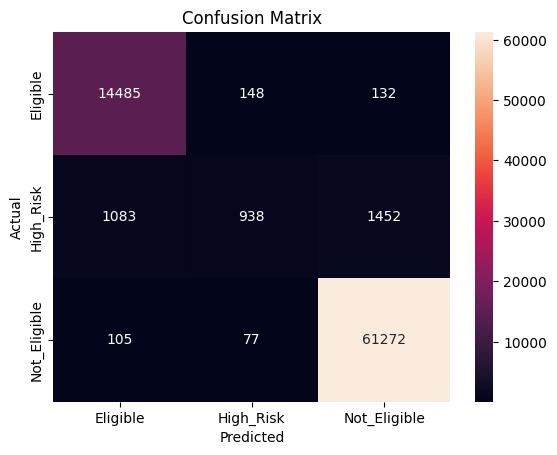

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', xticklabels=["Eligible", "High_Risk", "Not_Eligible"],
              yticklabels=["Eligible", "High_Risk", "Not_Eligible"]
            )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

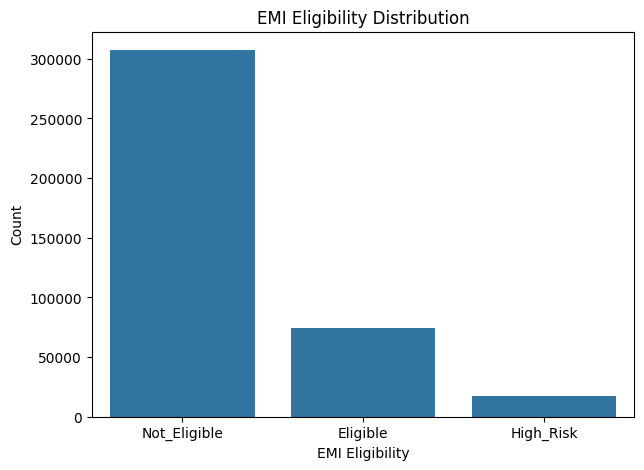

In [23]:
plt.figure(figsize=(7,5))
sns.countplot(x='emi_eligibility', data=df)
plt.title("EMI Eligibility Distribution")
plt.xlabel("EMI Eligibility")
plt.ylabel("Count")
plt.show()

In [13]:
xgb_model.feature_importances_

array([0.00215369, 0.05561295, 0.01278492, 0.01813644, 0.00222657,
       0.        , 0.00375   , 0.00499798, 0.0059087 , 0.02161093,
       0.00365257, 0.0189546 , 0.03020469, 0.02761714, 0.00429133,
       0.08124427, 0.05373465, 0.00455523, 0.01208338, 0.0739959 ,
       0.23132817, 0.00236879, 0.00244861, 0.00289503, 0.00261733,
       0.00289639, 0.02244446, 0.02110925, 0.00210999, 0.00223609,
       0.00282664, 0.00258724, 0.00253162, 0.02126419, 0.20168093,
       0.00273704, 0.00314483, 0.01656694, 0.01669043], dtype=float32)

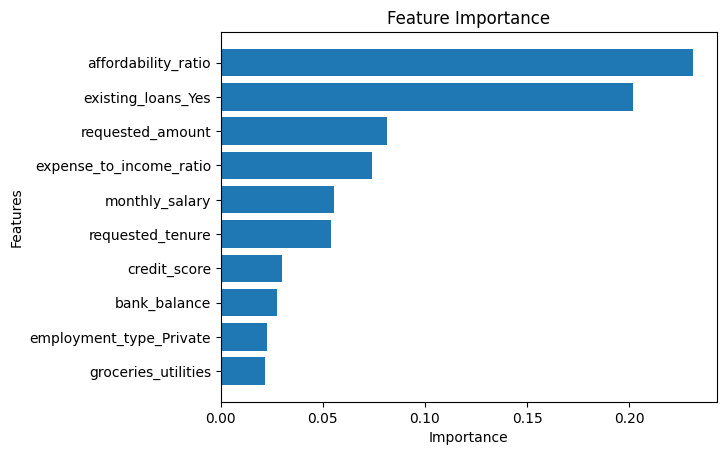

In [14]:
import matplotlib.pyplot as plt
importance_df = pd.DataFrame({
    "features": X.columns,
    "importance": xgb_model.feature_importances_
})
importance_df = importance_df.sort_values("importance", ascending=False).head(10)

plt.figure()
plt.barh(importance_df["features"], importance_df["importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()